# **Spam_Email_Detection**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import zipfile
object_zip=zipfile.ZipFile('/content/drive/MyDrive/Data Science/Project/SMS_Spam.zip')
object_zip.extractall()
object_zip.close()


In [3]:
df=pd.read_csv('/content/spam.csv',encoding='latin-1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)

In [6]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.rename(columns={'v1':'label','v2':'text'},inplace=True)

In [8]:
df.columns

Index(['label', 'text'], dtype='object')

In [9]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.shape

(5572, 2)

In [11]:
for i in range(10):
  print(df.iloc[i,-1])
  print()

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Ok lar... Joking wif u oni...

Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

U dun say so early hor... U c already then say...

Nah I don't think he goes to usf, he lives around here though

FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv

Even my brother is not like to speak with me. They treat me like aids patent.

As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune

WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.

Had your mobile 11 months or more?

In [12]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

In [13]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [14]:
sn=SnowballStemmer("english")


In [15]:
stop=set(stopwords.words('english'))

In [16]:
def clean_text(sms):
  sms=sms.lower()
  sms=re.sub(r'[^a-z0-9]',' ',sms)
  sms=nltk.word_tokenize(sms)
  sms=[t for t in sms if len(t)>1]
  sms=[sn.stem(word) for word in sms if word not in stop]
  sms=" ".join(sms)
  return sms


In [17]:
sent='Had your mobile playing 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030'

In [18]:
clean_text(sent)

'mobil play 11 month entitl updat latest colour mobil camera free call mobil updat co free 08002986030'

In [19]:
df['clean_text']=df['text'].apply(clean_text)

In [20]:
df.head()

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi great world l...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkts 21s...
3,ham,U dun say so early hor... U c already then say...,dun say earli hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


**WordCloud**

In [21]:
from wordcloud import WordCloud

In [22]:
hamdata=df[df['label']=='ham']
hamdata=hamdata['clean_text']

In [23]:
hamdata

,clean_text
0,go jurong point crazi avail bugi great world l...
1,ok lar joke wif oni
3,dun say earli hor alreadi say
4,nah think goe usf live around though
6,even brother like speak treat like aid patent
...,...
5565,huh lei
5568,go esplanad fr home
5569,piti mood suggest
5570,guy bitch act like interest buy someth els nex...


In [24]:
def wordCloud(data):
  words=' '.join(data)
  wc=WordCloud(background_color='white')
  wc.generate(words)

  plt.figure(figsize=(15,10))
  plt.imshow(wc)
  plt.axis('off')
  plt.show()

Ham data words: 


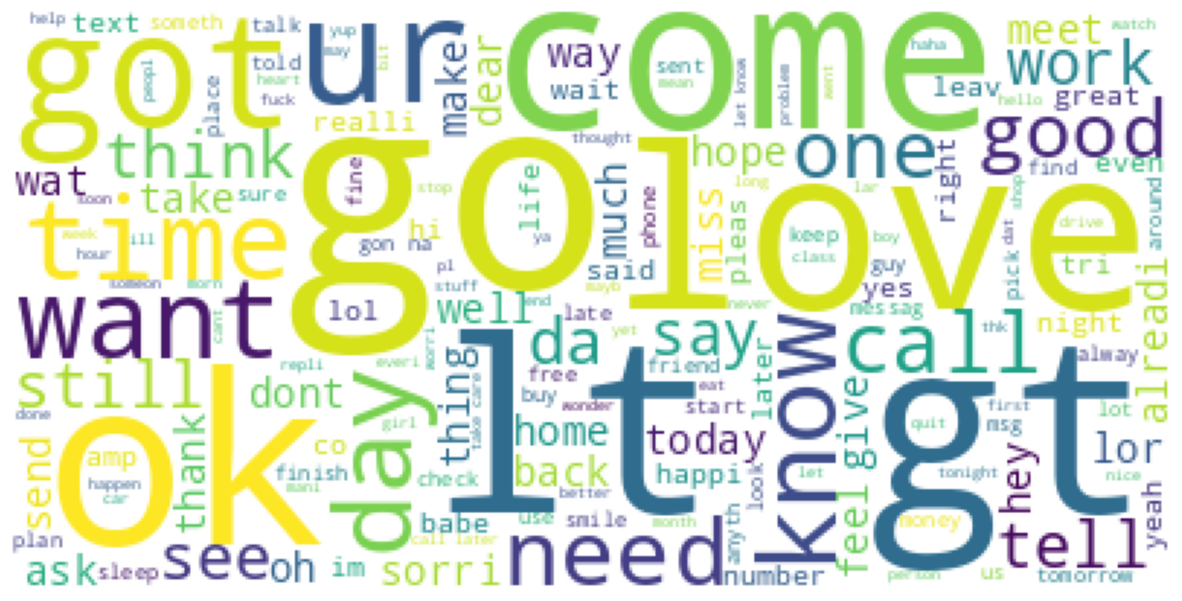

In [25]:
print("Ham data words: ")
wordCloud(hamdata)

In [26]:
spamdata=df[df['label']=='spam']
spamdata=spamdata['clean_text']

Spam data words: 


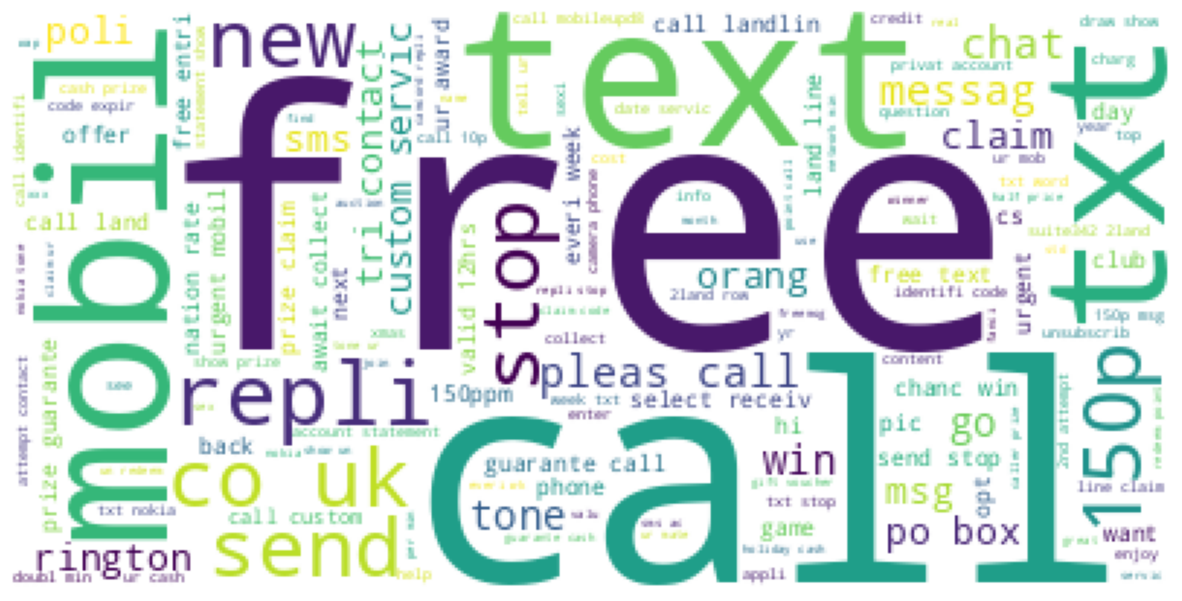

In [27]:
print("Spam data words: ")
wordCloud(spamdata)

F**eaturization**

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

In [29]:
cv=CountVectorizer(max_features=5000)
X=cv.fit_transform(df['clean_text']).toarray()

In [30]:
X.shape

(5572, 5000)

In [31]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [32]:
df['label']=df['label'].map({'ham':0,'spam':1})

In [33]:
y=df['label']

**Model Devlopment**

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.2,
                                               random_state=42)

In [35]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [36]:
y_pred=model.predict(X_test)

In [37]:
pd.DataFrame({'Actual':y_test,'Predicted':y_pred}).head(10)

,Actual,Predicted
3245,0,0
944,0,0
1044,1,1
2484,0,0
812,1,1
2973,0,0
2991,0,0
2942,0,0
230,0,0
1181,0,0


**Evaluation**

In [38]:
print("Accuracy on Traning data: ")
print(model.score(X_train,y_train))

Accuracy on Traning data: 
0.9916984518734575


In [39]:
print("Accuracy on Testing data: ")
print(model.score(X_test,y_test))

Accuracy on Testing data: 
0.979372197309417


In [40]:
from sklearn.metrics import confusion_matrix,\
                            f1_score,\
                            classification_report


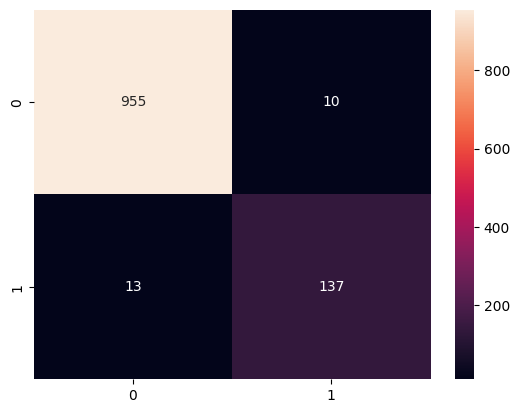

In [41]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot= True,fmt='d'  )
plt.show()

In [42]:
y_test.shape

(1115,)

In [43]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.93      0.91      0.92       150

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [44]:
f1_score(y_test,y_pred)

0.9225589225589226

In [45]:
import pickle
filename=open('model.pkl','wb')
pickle.dump(model,filename)